In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv('/kaggle/input/datasets/ivanpronin/dls-2026-tabels-my-tabels/train.csv')
test = pd.read_csv('/kaggle/input/datasets/ivanpronin/dls-2026-tabels-my-tabels/test.csv', delimiter=';')


In [3]:
test.head()

,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,target
0,-0.216602,-0.409942,-0.793007,-0.182019,0.456179,0.679295,-0.054357,-0.610204,0.538304,-0.877190,...,-0.359468,-1.625439,-1.445561,-0.138313,-0.588435,0.000378,0.004201,1.086587,1.256643,NaN
1,-0.001979,0.033323,0.186686,0.052808,0.530093,0.572632,0.348396,0.547413,0.448930,-0.238995,...,-0.339738,-0.071876,0.184033,0.316441,-0.080179,0.169904,0.872442,0.525727,1.080996,NaN
2,-0.862840,-2.821202,-7.115937,-0.049643,-0.640602,-0.372096,-0.357179,-0.235255,-0.366530,0.606603,...,-0.572275,0.541386,-3.184798,0.078175,0.424794,0.294532,0.004770,-0.586464,-0.642643,NaN
3,-1.155652,-0.877204,-1.637323,-2.031945,-2.149620,-0.342989,-0.537687,-1.271010,-0.447697,-1.002444,...,-1.022199,-0.916196,-0.760066,-0.468984,-0.403156,-0.669043,-0.932063,-0.355592,-0.445002,NaN
4,-0.182728,0.060722,0.104551,0.013138,-0.584910,-0.257986,-0.170301,0.820766,-0.348146,0.301128,...,-0.349020,0.544159,0.434295,0.375552,0.310798,-0.377300,0.208898,-0.048483,-0.539068,NaN


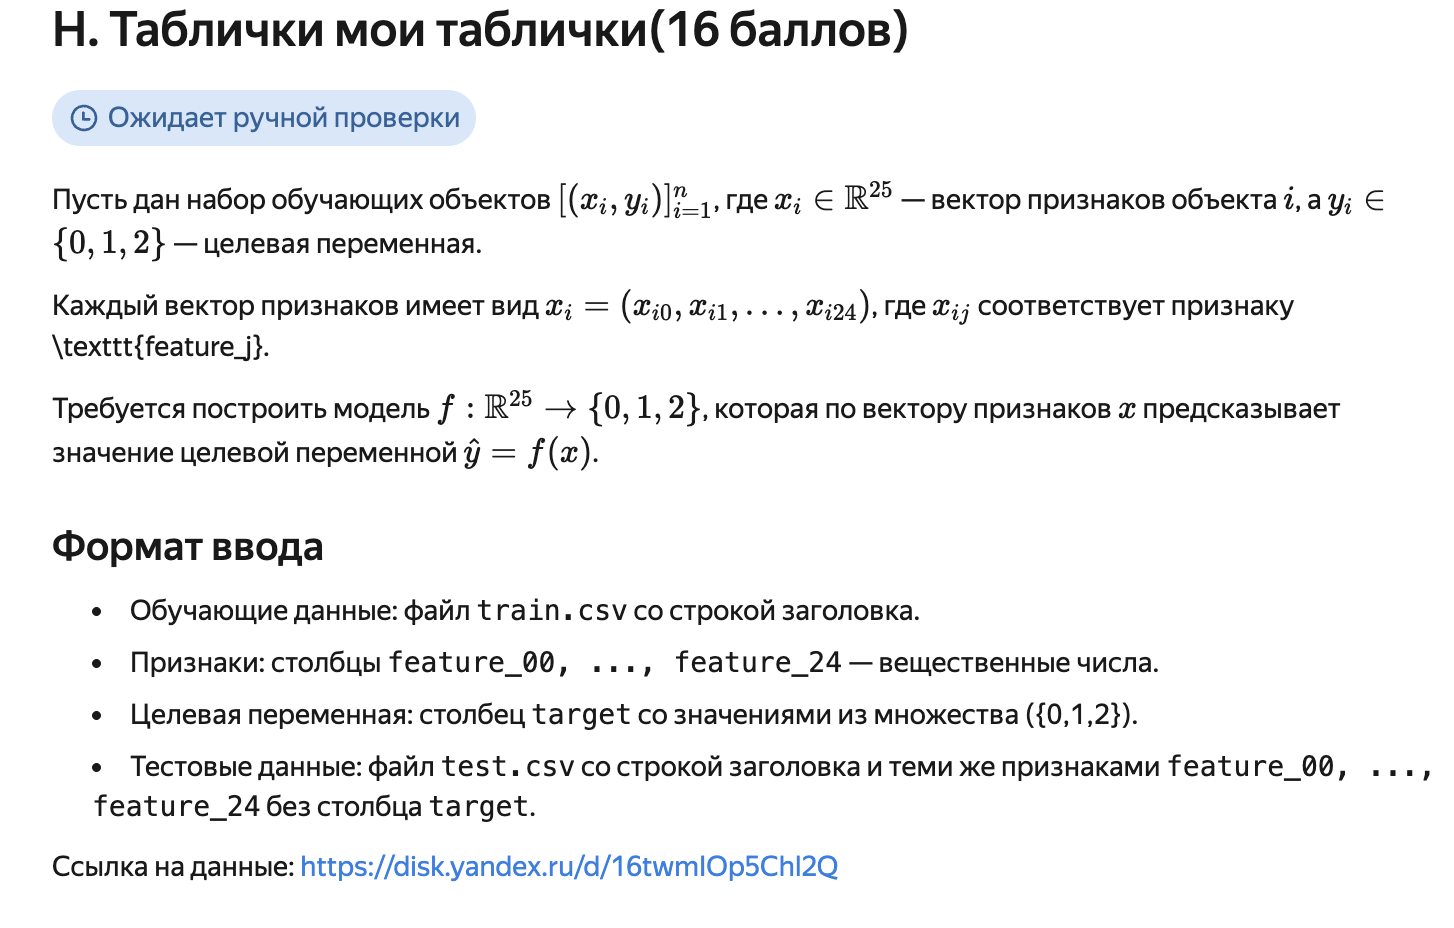

In [6]:
X = train.drop(['target'], axis=1)
Y = train['target']


In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.1, shuffle=True)

In [25]:
train_df, val_df = train_test_split(train, test_size=0.15, shuffle=True)

In [123]:
pip install tabicl skrub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 9.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [135]:
from skrub import TableVectorizer
from tabicl import TabICLClassifier
from sklearn.pipeline import make_pipeline


clf = TabICLClassifier(
    n_estimators=30,  # number of ensemble members, more = better but slower
    norm_methods='power',  # normalization methods to try
    feat_shuffle_method="latin",  # feature permutation strategy
    class_shuffle_method="shift",  # class permutation strategy
    outlier_threshold=6,  # z-score threshold for outlier detection and clipping
    softmax_temperature=1.5,  # temperature to control prediction confidence
    average_logits=True,  # average logits (True) or probabilities (False)
    support_many_classes=False,  # handle >10 classes automatically
    batch_size=16,  # ensemble members processed together, lower to save memory
    model_path=None,  # path to checkpoint, None downloads from Hugging Face
    allow_auto_download=True,  # auto-download checkpoint if not found locally
    checkpoint_version="tabicl-classifier-v2-20260212.ckpt",  # pretrained checkpoint version
    device=None,  # inference device, None auto-selects CUDA or CPU
    use_amp="auto",  # automatic mixed precision for faster inference
    use_fa3="auto",  # Flash Attention 3 for Hopper GPUs (e.g. H100)
    offload_mode="auto",  # automatically decide when to use cpu/disk offloading
    disk_offload_dir=None,  # directory for disk offloading
    random_state=42,  # random seed for reproducibility
    n_jobs=None,  # number of PyTorch threads for CPU inference
    verbose=True,  # print detailed information during inference
    inference_config=None,  # fine-grained inference control for advanced users
)

In [136]:
pipeline = make_pipeline(
    TableVectorizer(low_cardinality="passthrough"),  # Automatically handles various data types
    clf
)

pipeline.fit(X_train, y_train)  # X should be a DataFrame

Columns classified as categorical: []
Columns classified as continuous: ['feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24']


Pipeline(steps=[('tablevectorizer',
                 TableVectorizer(low_cardinality='passthrough')),
                ('tabiclclassifier',
                 TabICLClassifier(batch_size=16, n_estimators=30,
                                  norm_methods='power', outlier_threshold=6,
                                  softmax_temperature=1.5,
                                  support_many_classes=False, verbose=True))])

In [137]:
predictions = pipeline.predict(X_val)


Available GPU memory: 14.05GB, seq_len: 10000, estimated batch size for tf_col: 232
Offload decision: mode=GPU (reason=auto_gpu_fits: 2124MB <= 7196MB safe gpu free)
Output size: 2.07GB (repeat=1), CPU free: 27.95GB, GPU free: 14.05GB, Disk free (effective): 0.00GB @ None


Processing tf_col:   0%|          | 0/2 [00:00<?, ?batch/s]


Available GPU memory: 12.11GB, seq_len: 29, estimated batch size for tf_row: 50000
Offload decision: mode=GPU (reason=user_gpu_fits: 293MB <= 12404MB gpu free)
Output size: 0.29GB (repeat=1), CPU free: 27.93GB, GPU free: 12.11GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/4 [00:00<?, ?batch/s]


Available GPU memory: 13.90GB, seq_len: 10000, estimated batch size for tf_icl: 57
Offload decision: mode=GPU (reason=user_gpu_fits: 6MB <= 14236MB gpu free)
Output size: 0.01GB (repeat=1), CPU free: 27.93GB, GPU free: 13.90GB, Disk free (effective): 0.00GB @ None

Available GPU memory: 14.04GB, seq_len: 10000, estimated batch size for tf_col: 232
Offload decision: mode=GPU (reason=auto_gpu_fits: 2124MB <= 7191MB safe gpu free)
Output size: 2.07GB (repeat=1), CPU free: 27.93GB, GPU free: 14.04GB, Disk free (effective): 0.00GB @ None


Processing tf_col:   0%|          | 0/2 [00:00<?, ?batch/s]


Available GPU memory: 12.11GB, seq_len: 29, estimated batch size for tf_row: 50000
Offload decision: mode=GPU (reason=user_gpu_fits: 293MB <= 12404MB gpu free)
Output size: 0.29GB (repeat=1), CPU free: 27.93GB, GPU free: 12.11GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/4 [00:00<?, ?batch/s]


Available GPU memory: 13.90GB, seq_len: 10000, estimated batch size for tf_icl: 57
Offload decision: mode=GPU (reason=user_gpu_fits: 6MB <= 14236MB gpu free)
Output size: 0.01GB (repeat=1), CPU free: 27.93GB, GPU free: 13.90GB, Disk free (effective): 0.00GB @ None


In [138]:
f1_score(y_val, predictions,  average='macro')

0.9039552725351028

In [139]:
accuracy_score(y_val, predictions)

0.906

In [140]:
X_val.head()

,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
2777,0.059281,-0.767591,-1.562039,-0.314610,-0.426731,0.001789,-0.355681,-0.825781,0.127686,0.291213,...,-0.187058,-0.222579,-0.076047,-1.547220,-0.037071,0.042364,-0.145635,-0.666973,0.107807,0.097833
548,-0.055543,0.225514,0.366153,-0.791654,-1.288833,-0.866166,-0.891055,0.110178,-0.921746,-0.548036,...,-1.458201,-0.231891,-0.324606,0.714810,0.026491,-0.140255,-0.260321,-0.604840,-1.597496,-1.367721
2736,-1.201513,-1.627277,-1.465128,0.619155,1.147472,0.217902,0.596144,-0.744704,0.197611,0.072534,...,0.830182,-0.687134,-0.036874,-1.539071,-0.047014,0.036152,-0.511915,-0.513530,0.899695,0.553809
4516,0.245736,0.559947,1.424430,1.196276,1.176254,0.027624,0.681933,1.006049,0.150918,0.772355,...,0.554194,-0.044801,1.117326,1.398450,0.487607,0.443589,0.066300,1.241520,0.724742,0.388513
8169,-0.703505,-0.857377,-0.814052,0.006500,0.883269,0.920501,0.537057,-1.166326,0.837729,-0.981358,...,1.374144,-0.614538,-0.994898,-1.100819,-0.612216,-0.450137,-0.819762,-0.796674,1.419308,1.088138


In [141]:
test.head()

,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,target
0,-0.216602,-0.409942,-0.793007,-0.182019,0.456179,0.679295,-0.054357,-0.610204,0.538304,-0.877190,...,-0.359468,-1.625439,-1.445561,-0.138313,-0.588435,0.000378,0.004201,1.086587,1.256643,NaN
1,-0.001979,0.033323,0.186686,0.052808,0.530093,0.572632,0.348396,0.547413,0.448930,-0.238995,...,-0.339738,-0.071876,0.184033,0.316441,-0.080179,0.169904,0.872442,0.525727,1.080996,NaN
2,-0.862840,-2.821202,-7.115937,-0.049643,-0.640602,-0.372096,-0.357179,-0.235255,-0.366530,0.606603,...,-0.572275,0.541386,-3.184798,0.078175,0.424794,0.294532,0.004770,-0.586464,-0.642643,NaN
3,-1.155652,-0.877204,-1.637323,-2.031945,-2.149620,-0.342989,-0.537687,-1.271010,-0.447697,-1.002444,...,-1.022199,-0.916196,-0.760066,-0.468984,-0.403156,-0.669043,-0.932063,-0.355592,-0.445002,NaN
4,-0.182728,0.060722,0.104551,0.013138,-0.584910,-0.257986,-0.170301,0.820766,-0.348146,0.301128,...,-0.349020,0.544159,0.434295,0.375552,0.310798,-0.377300,0.208898,-0.048483,-0.539068,NaN


In [142]:
test_predictions = pipeline.predict(test.drop('target', axis=1))
sub = pd.DataFrame(test_predictions, columns=['tagret'])
sub.to_csv('tabels_sub_tabcl.csv', index=False)


Available GPU memory: 14.04GB, seq_len: 14000, estimated batch size for tf_col: 165
Offload decision: mode=GPU (reason=auto_gpu_fits: 2974MB <= 7191MB safe gpu free)
Output size: 2.90GB (repeat=1), CPU free: 27.94GB, GPU free: 14.04GB, Disk free (effective): 0.00GB @ None


Processing tf_col:   0%|          | 0/3 [00:00<?, ?batch/s]


Available GPU memory: 11.28GB, seq_len: 29, estimated batch size for tf_row: 50000
Offload decision: mode=GPU (reason=user_gpu_fits: 410MB <= 11556MB gpu free)
Output size: 0.40GB (repeat=1), CPU free: 27.94GB, GPU free: 11.28GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/5 [00:00<?, ?batch/s]


Available GPU memory: 13.79GB, seq_len: 14000, estimated batch size for tf_icl: 40
Offload decision: mode=GPU (reason=user_gpu_fits: 8MB <= 14118MB gpu free)
Output size: 0.01GB (repeat=1), CPU free: 27.92GB, GPU free: 13.79GB, Disk free (effective): 0.00GB @ None

Available GPU memory: 13.98GB, seq_len: 14000, estimated batch size for tf_col: 165
Offload decision: mode=GPU (reason=auto_gpu_fits: 2974MB <= 7156MB safe gpu free)
Output size: 2.90GB (repeat=1), CPU free: 27.92GB, GPU free: 13.98GB, Disk free (effective): 0.00GB @ None


Processing tf_col:   0%|          | 0/3 [00:00<?, ?batch/s]


Available GPU memory: 11.27GB, seq_len: 29, estimated batch size for tf_row: 50000
Offload decision: mode=GPU (reason=user_gpu_fits: 410MB <= 11544MB gpu free)
Output size: 0.40GB (repeat=1), CPU free: 27.92GB, GPU free: 11.27GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/5 [00:00<?, ?batch/s]


Available GPU memory: 13.78GB, seq_len: 14000, estimated batch size for tf_icl: 40
Offload decision: mode=GPU (reason=user_gpu_fits: 8MB <= 14106MB gpu free)
Output size: 0.01GB (repeat=1), CPU free: 27.91GB, GPU free: 13.78GB, Disk free (effective): 0.00GB @ None
